In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xesmf as xe
import dask
from scipy.ndimage import label, binary_dilation
from scipy.ndimage import distance_transform_edt

In [2]:
PATH_NCEP_R1 = '/glade/campaign/cgd/oce/people/rita/NCEP_R1/'
PATH_NCEP_R2 = '/glade/campaign/cgd/oce/people/rita/NCEP_R2/'
PATH_CFSR = '/glade/campaign/cgd/oce/people/rita/CFSR/'
PATH_CFSv2 = '/glade/campaign/cgd/oce/people/rita/CFSv2/'
PATH_MERRA2 = '/glade/campaign/cgd/oce/people/rita/MERRA2/'
PATH_JRA3Q = '/glade/campaign/cgd/oce/people/rita/JRA-3Q/'
PATH_JRAdo = '/glade/campaign/cgd/oce/people/rita/JRA55do/'
PATH_20CRv3 = '/glade/campaign/cgd/oce/people/rita/20CRv3/'
PATH_ERA5 = '/glade/campaign/cgd/oce/people/rita/ERA5/'
PATH_ERAi = '/glade/campaign/cgd/oce/people/rita/ERA-Interim/'
PATH_ERA20C = '/glade/campaign/cgd/oce/people/rita/ERA20C/'

filename_NCEP_R1 = 'air.2m.gauss.monthly_1948_2025.nc'
filename_NCEP_R2 = 'air.2m.gauss.monthly_1979_2025.nc'
filename_CFSR = 'tmp2m.monthly_1979_2010.nc'
filename_CFSv2 = 'tmp2m.monthly_2011_2020.nc' 
filename_MERRA2 = 'T2M_MERRA2.monthly_1980_2024.nc'
filename_JRA3Q = 'tmp2m.monthly.1947_2025.nc'
filename_JRAdo = 't_2.converted.reg_tl319.monthly_1958_2019.nc'
filename_20CRv3 = 'air.2m.monthly.1900_2015.nc'
filename_ERA5 = 'T2M.monthly_1940_2020.nc'
filename_ERAi = 'tmp2m_monthly_1979_2019.nc'
filename_ERA20C = '2t.monthly_1900_2010.nc'


varname_NCEP_R1 = 'air'
varname_NCEP_R2 = 'air'
varname_CFSR = '2t'
varname_CFSv2 = '2t'
varname_MERRA2 = 'T2M'
varname_JRA3Q = 'tmp2m-hgt-fc-gauss'
varname_JRAdo = 't_2'
varname_20CRv3 = 'air'
varname_ERA5 = 'T2M'
varname_ERAi = 'var167'
varname_ERA20C = 'var167'

# Plot T2 time series 
in all reanalyses, their mean, and corrected ERA5

In [3]:
filename_NCEP_R1 = 'air.2m.gauss.yearly_1948_2025.nc'
filename_NCEP_R2 = 'air.2m.gauss.yearly_1979_2025.nc'
filename_CFSR = 'tmp2m.yearly_1979_2010.nc'
filename_CFSv2 = 'tmp2m.yearly_2011_2020.nc' 
filename_MERRA2 = 'T2M_MERRA2.yearly_1980_2024.nc'
filename_JRA3Q = 'tmp2m.yearly.1947_2025.nc'
filename_JRAdo = 't_2.converted.reg_tl319.yearly_1958_2019.nc'
filename_20CRv3 = 'air.2m.yearly.1900_2015.nc'
filename_ERA5 = 'T2M.yearly_1940_2020.nc'
filename_ERA5_corrected_same_cor = 'T2M_corrected_v1.yearly_1940_2020.nc'
filename_ERA5_corrected_dif_base_periods = 'T2M_corrected_v1.yearly_1940_2020_with_1958_1979_base_period.nc'
filename_ERAi = 'tmp2m_yearly_1979_2019.nc'
filename_ERA20C = '2t.yearly_1900_2010.nc'

In [4]:
mask_era5 = xr.open_dataset(PATH_ERA5 + '1940/194001_hres_cisst.nc', decode_times=False).isel(time=0)
ocean_mask = xr.where(mask_era5.SSTK.notnull(), 1, 0)
# ocean_mask.to_netcdf(PATH_ERA5 + "era5_landsea_mask.nc")

In [5]:
%%time
print('computing yearly means (for full years)')
print('ncep r1/r2..')
t2_ncep_r1 = xr.open_dataset(PATH_NCEP_R1 + filename_NCEP_R1)[varname_NCEP_R1].sel(time=slice("1948", "2024"))
t2_ncep_r2 = xr.open_dataset(PATH_NCEP_R2 + filename_NCEP_R2)[varname_NCEP_R2].sel(time=slice("1979", "2024"))
print('cfsr v1/v2..')
t2_cfsr = xr.open_dataset(PATH_CFSR + filename_CFSR)[varname_CFSR]
t2_cfsv2 = xr.open_dataset(PATH_CFSv2 + filename_CFSv2)[varname_CFSv2]
print('merra..')
t2_merra2 = xr.open_dataset(PATH_MERRA2 + filename_MERRA2)[varname_MERRA2]
print('jra 3q..')
t2_jra3q = xr.open_dataset(PATH_JRA3Q + filename_JRA3Q)[varname_JRA3Q].sel(time=slice("1948", "2024"))
print('jra do..')
t2_jrado = xr.open_dataset(PATH_JRAdo + filename_JRAdo)[varname_JRAdo]
new_time = pd.to_datetime(t2_jrado.time.astype(str))
t2_jrado['time'] = ('time', new_time)
print('20crv..')
t2_20crv3 = xr.open_dataset(PATH_20CRv3 + filename_20CRv3)[varname_20CRv3]
print('era5..')
t2_era5 = xr.open_dataset(PATH_ERA5 + filename_ERA5)[varname_ERA5]
print('era5(corrected, same base period)..')
t2_era5_corrected_same_cor = xr.open_dataset(PATH_ERA5 + filename_ERA5_corrected_same_cor)[varname_ERA5]
print('era5(corrected, dif periods)..')
t2_era5_corrected_dif_base_periods = xr.open_dataset(PATH_ERA5 + filename_ERA5_corrected_dif_base_periods)[varname_ERA5]
print('erai..')
t2_erai = xr.open_dataset(PATH_ERAi + filename_ERAi)[varname_ERAi].sel(time=slice("1979", "2018"))
print('era20c..')
t2_era20c = xr.open_dataset(PATH_ERA20C + filename_ERA20C)[varname_ERA20C]

computing yearly means (for full years)
ncep r1/r2..
cfsr v1/v2..
merra..
jra 3q..
jra do..
20crv..
era5..
era5(corrected, same base period)..
era5(corrected, dif periods)..
erai..
era20c..
CPU times: user 109 ms, sys: 39.1 ms, total: 148 ms
Wall time: 2.13 s


In [6]:
# reorder MERRA so its lons go from -180:180 - otherwise it doesn't regrid to ERA5 grid correctly 
merra2_shifted = t2_merra2.copy()
merra2_shifted['lon'] = (merra2_shifted.lon + 360) % 360
merra2_shifted = merra2_shifted.sortby('lon')

In [7]:
%%time
print('interpolating data to ERA5 grid...')
target_lat = t2_era5.lat
target_lon = t2_era5.lon

print('NCEP R1/R2...')
t2_ncep_r1_interp = t2_ncep_r1.interp(lat=target_lat, lon=target_lon)
t2_ncep_r2_interp = t2_ncep_r2.interp(lat=target_lat, lon=target_lon)
print('CFSR/CFSv2...')
t2_cfsr_interp = t2_cfsr.interp(lat=target_lat, lon=target_lon).isel(height = 0)
t2_cfsv2_interp = t2_cfsv2.interp(lat=target_lat, lon=target_lon).isel(height = 0)
print('MERRA2...')
t2_merra2_interp = merra2_shifted.interp(lat=target_lat, lon=target_lon)
print('JRA3Q...')
t2_jra3q_interp = t2_jra3q.interp(lat=target_lat, lon=target_lon)
print('JRAdo...')
t2_jrado_interp = t2_jrado.interp(latitude=target_lat, longitude=target_lon)
print('20CRv3...')
t2_20crv3_interp = t2_20crv3.interp(lat=target_lat, lon=target_lon)
print('ERAi...')
t2_erai_interp = t2_erai.interp(lat=target_lat, lon=target_lon)
print('ERA20C')
t2_era20c_interp = t2_era20c.interp(lat=target_lat, lon=target_lon)
print('done!')

interpolating data to ERA5 grid...
NCEP R1/R2...
CFSR/CFSv2...
MERRA2...
JRA3Q...
JRAdo...
20CRv3...
ERAi...
ERA20C
done!
CPU times: user 5.9 s, sys: 8.39 s, total: 14.3 s
Wall time: 32.2 s


In [8]:
t2_cfsr_interp = xr.concat([t2_cfsr_interp, t2_cfsv2_interp], dim="rean").mean(dim="rean", skipna=True)

In [9]:
%%time
# this is to leave only years that overlap with ERA5
# (we can also use this to compute weigthed mean later)
common_time = t2_era5.time
t2_ncep_r1_interp = t2_ncep_r1_interp.interp(time=common_time)
t2_ncep_r2_interp = t2_ncep_r2_interp.interp(time=common_time)
t2_cfsr_interp = t2_cfsr_interp.interp(time=common_time)
t2_merra2_interp = t2_merra2_interp.interp(time=common_time)
t2_jra3q_interp = t2_jra3q_interp.interp(time=common_time)
t2_jrado_interp = t2_jrado_interp.interp(time=common_time)
t2_20crv3_interp = t2_20crv3_interp.interp(time=common_time)
t2_erai_interp = t2_erai_interp.interp(time=common_time)
t2_era20c_interp = t2_era20c_interp.interp(time=common_time)

CPU times: user 8.65 s, sys: 15.6 s, total: 24.3 s
Wall time: 1min 19s


In [10]:
def compute_weighted_mean(data, lat_name='lat', lon_name='lon', mask=None):
    """
    Compute weighted spatial mean over lat-lon for a DataArray with time dimension.

    Parameters:
        data (xr.DataArray): The input data with dimensions (time, lat, lon).
        lat_name (str): Name of the latitude dimension. Default: 'lat'.
        lon_name (str): Name of the longitude dimension. Default: 'lon'.
        mask (xr.DataArray or np.ndarray): Optional mask to apply (1 = keep, 0 = mask out).

    Returns:
        xr.DataArray: 1D time series of spatially averaged values.
    """
    # Build cosine latitude weights
    weights = np.cos(np.deg2rad(data[lat_name]))

    # Convert to DataArray and align dims
    weights = xr.DataArray(weights, coords={lat_name: data[lat_name]}, dims=[lat_name])

    # Broadcast weights to match data shape
    weights = weights.broadcast_like(data)

    # Apply mask if provided
    if mask is not None:
        weights = weights * mask

    # Normalize weights so they sum to 1 at each time (safe for Dask)
    weights = weights / weights.sum(dim=[lat_name, lon_name])

    # Compute weighted mean
    weighted_mean = data.weighted(weights).mean(dim=[lat_name, lon_name])

    return weighted_mean


In [11]:
t2_ncep_r1_mean = compute_weighted_mean(t2_ncep_r1_interp, mask=ocean_mask)
t2_ncep_r2_mean = compute_weighted_mean(t2_ncep_r2_interp, mask=ocean_mask)
t2_cfsr_mean    = compute_weighted_mean(t2_cfsr_interp, mask=ocean_mask)
t2_merra2_mean  = compute_weighted_mean(t2_merra2_interp, mask=ocean_mask)
t2_jra3q_mean   = compute_weighted_mean(t2_jra3q_interp, mask=ocean_mask)
t2_jrado_mean   = compute_weighted_mean(t2_jrado_interp, mask=ocean_mask)
t2_20crv3_mean  = compute_weighted_mean(t2_20crv3_interp, mask=ocean_mask)
t2_erai_mean    = compute_weighted_mean(t2_erai_interp, mask=ocean_mask)
t2_era20c_mean  = compute_weighted_mean(t2_era20c_interp, mask=ocean_mask)
t2_era5_mean    = compute_weighted_mean(t2_era5, mask=ocean_mask)
t2_era5_corrected_same_cor_mean    = compute_weighted_mean(t2_era5_corrected_same_cor, mask=ocean_mask)
t2_era5_corrected_dif_base_periods_mean    = compute_weighted_mean(t2_era5_corrected_dif_base_periods, mask=ocean_mask)

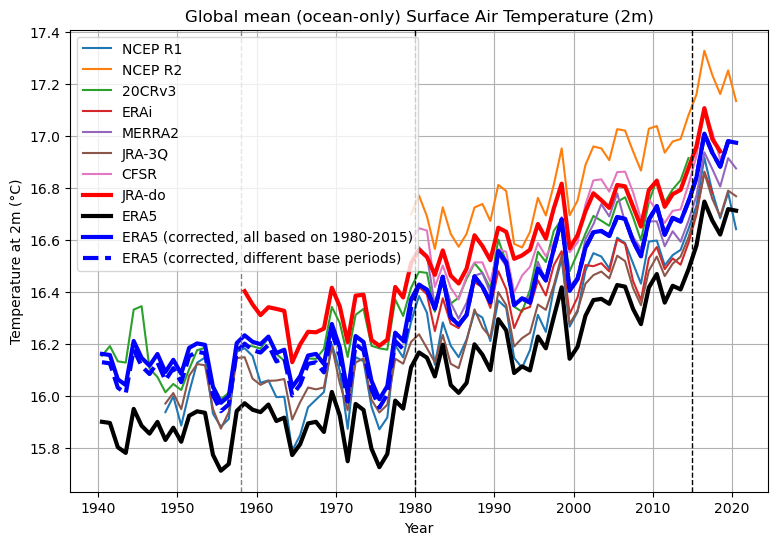

In [12]:
plt.figure(figsize=(9, 6))
n_lines = 9
# colors = cm.plasma(np.linspace(0, 1, n_lines))

# (t2_ncep_r1_mean - 273.15).plot(label = 'NCEP R1', c = 'red')
# (t2_ncep_r2_mean - 273.15).plot(label = 'NCEP R2', c = 'orangered')
# (t2_era20c_mean - 273.15).plot(label = 'ERA20C', c = 'orange', linestyle='--')
# (t2_20crv3_mean - 273.15).plot(label = '20CRv3', c = 'green')
# (t2_erai_mean - 273.15).plot(label = 'ERAi', c = 'dodgerblue')
# (t2_merra2_mean - 273.15).plot(label = 'MERRA2', c = 'blue')
# (t2_jra3q_mean - 273.15).plot(label = 'JRA-3Q', c = 'darkviolet')
# (t2_cfsr_mean - 273.15).plot(label = 'CFSR', c = 'magenta')


(t2_ncep_r1_mean - 273.15).plot(label = 'NCEP R1')
(t2_ncep_r2_mean - 273.15).plot(label = 'NCEP R2')
# (t2_era20c_mean - 273.15).plot(label = 'ERA20C', linestyle='--')
(t2_20crv3_mean - 273.15).plot(label = '20CRv3')
(t2_erai_mean - 273.15).plot(label = 'ERAi')
(t2_merra2_mean - 273.15).plot(label = 'MERRA2')
(t2_jra3q_mean - 273.15).plot(label = 'JRA-3Q')
(t2_cfsr_mean - 273.15).plot(label = 'CFSR')


(t2_jrado_mean - 273.15).plot(label = 'JRA-do', c = 'r', linewidth=3)
(t2_era5_mean - 273.15).plot(label = 'ERA5', c = 'k', linewidth=3)
(t2_era5_corrected_same_cor_mean - 273.15).plot(label = 'ERA5 (corrected, all based on 1980-2015)', c = 'b', linewidth=3)
(t2_era5_corrected_dif_base_periods_mean - 273.15).plot(label = 'ERA5 (corrected, different base periods)', linestyle='--', c = 'b', linewidth=3)

# plt.axvline(x=pd.Timestamp('1948-01-01'), color='k', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('1958-01-01'), color='grey', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('1980-01-01'), color='k', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('2015-01-01'), color='k', linestyle='--', linewidth=1)
# plt.axvline(x=pd.Timestamp('2007-01-01'), color='gray', linestyle='--', linewidth=1)
plt.xlabel('Year')
plt.ylabel('Temperature at 2m (°C)')
plt.title('Global mean (ocean-only) Surface Air Temperature (2m)')
plt.grid(True)
plt.legend()

In [13]:
# Stack your time series into a 2D array: (ensemble, time)
datasets = np.stack([
    t2_ncep_r1_mean,
    t2_ncep_r2_mean.isel(level=0),
    # t2_era20c_mean,
    t2_20crv3_mean,
    t2_cfsr_mean,
    t2_merra2_mean,
    t2_jra3q_mean,
    t2_erai_mean
])

# Convert to Celsius if needed
datasets = datasets - 273.15

# Define weights: shape (ensemble,)
# weights = np.array([0.5, 0.5, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0])
weights = np.array([0.5, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0])


# # Weighted average over the first axis (ensemble)
# ens_mean_weighted_np = np.sum(weights[:, None] * datasets, axis=0) / np.sum(weights)

# # Re-wrap as DataArray
# ens_mean_weighted = xr.DataArray(
#     ens_mean_weighted_np,
#     dims=["time"],
#     coords={"time": t2_era20c_interp.time},  # or whatever shared time axis you used
#     name="t2_ensemble_mean"
# )


# Step 4: Expand weights to (ensemble, time)
weights_expanded = np.broadcast_to(weights[:, None], datasets.shape)

# Step 5: Use np.nansum to ignore NaNs in numerator and denominator
numerator = np.nansum(weights_expanded * datasets, axis=0)
denominator = np.nansum(weights_expanded * ~np.isnan(datasets), axis=0)

ens_mean_weighted_np = numerator / denominator


ens_mean_weighted = xr.DataArray(
    ens_mean_weighted_np,
    dims=["time"],
    coords={"time": t2_era20c_mean.time},
    name="t2_ensemble_mean"
)

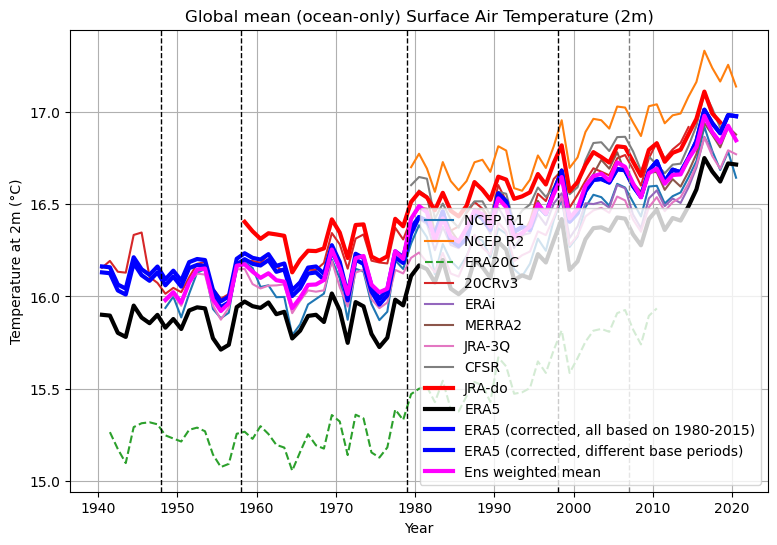

In [15]:
plt.figure(figsize=(9, 6))

(t2_ncep_r1_mean - 273.15).plot(label = 'NCEP R1')
(t2_ncep_r2_mean - 273.15).plot(label = 'NCEP R2')
(t2_era20c_mean - 273.15).plot(label = 'ERA20C', linestyle='--')
(t2_20crv3_mean - 273.15).plot(label = '20CRv3')
(t2_erai_mean - 273.15).plot(label = 'ERAi')
(t2_merra2_mean - 273.15).plot(label = 'MERRA2')
(t2_jra3q_mean - 273.15).plot(label = 'JRA-3Q')
(t2_cfsr_mean - 273.15).plot(label = 'CFSR')


(t2_jrado_mean - 273.15).plot(label = 'JRA-do', c = 'r', linewidth=3)
(t2_era5_mean - 273.15).plot(label = 'ERA5', c = 'k', linewidth=3)
(t2_era5_corrected_same_cor_mean - 273.15).plot(label = 'ERA5 (corrected, all based on 1980-2015)', c = 'b', linewidth=3)
(t2_era5_corrected_dif_base_periods_mean - 273.15).plot(label = 'ERA5 (corrected, different base periods)', c = 'b', linewidth=3)

ens_mean_weighted.sel(time = slice("1948", "2020")).plot(label = 'Ens weighted mean', linewidth=3, c = "magenta")

plt.axvline(x=pd.Timestamp('1948-01-01'), color='k', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('1958-01-01'), color='k', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('1979-01-01'), color='k', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('1998-01-01'), color='k', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('2007-01-01'), color='gray', linestyle='--', linewidth=1)
plt.xlabel('Year')
plt.ylabel('Temperature at 2m (°C)')
plt.title('Global mean (ocean-only) Surface Air Temperature (2m)')
plt.grid(True)
plt.legend()

# Do the same but only for the Arctic region (>60ºN)

In [45]:
sst_era5 = xr.open_dataset(PATH_ERA5 + 'SST_ICE_MONTHLY/sst_ice_yearly.1940_2023.nc')['SST_cpl'].rename({'latitude':'lat', 'longitude': 'lon'})

In [47]:
t2_ncep_r1_mean = compute_weighted_mean(t2_ncep_r1_interp.sel(lat = slice(90,60)), mask=ocean_mask)
t2_ncep_r2_mean = compute_weighted_mean(t2_ncep_r2_interp.sel(lat = slice(90,60)), mask=ocean_mask)
t2_cfsr_mean    = compute_weighted_mean(t2_cfsr_interp.sel(lat = slice(90,60)), mask=ocean_mask)
t2_merra2_mean  = compute_weighted_mean(t2_merra2_interp.sel(lat = slice(90,60)), mask=ocean_mask)
t2_jra3q_mean   = compute_weighted_mean(t2_jra3q_interp.sel(lat = slice(90,60)), mask=ocean_mask)
t2_jrado_mean   = compute_weighted_mean(t2_jrado_interp.sel(lat = slice(90,60)), mask=ocean_mask)
t2_20crv3_mean  = compute_weighted_mean(t2_20crv3_interp.sel(lat = slice(90,60)), mask=ocean_mask)
t2_erai_mean    = compute_weighted_mean(t2_erai_interp.sel(lat = slice(90,60)), mask=ocean_mask)
t2_era20c_mean  = compute_weighted_mean(t2_era20c_interp.sel(lat = slice(90,60)), mask=ocean_mask)
t2_era5_mean    = compute_weighted_mean(t2_era5.sel(lat = slice(90,60)), mask=ocean_mask)
t2_era5_corrected_same_cor_mean    = compute_weighted_mean(t2_era5_corrected_same_cor.sel(lat = slice(90,60)), mask=ocean_mask)
t2_era5_corrected_dif_base_periods_mean    = compute_weighted_mean(t2_era5_corrected_dif_base_periods.sel(lat = slice(90,60)), mask=ocean_mask)

sst_era5_mean    = compute_weighted_mean(sst_era5.sel(lat = slice(60,90)), mask=ocean_mask)

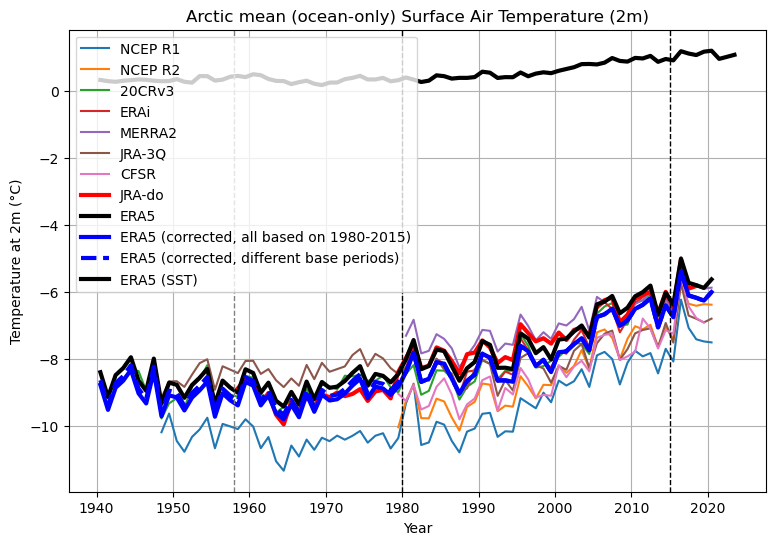

In [49]:
plt.figure(figsize=(9, 6))
n_lines = 9
# colors = cm.plasma(np.linspace(0, 1, n_lines))

# (t2_ncep_r1_mean - 273.15).plot(label = 'NCEP R1', c = 'red')
# (t2_ncep_r2_mean - 273.15).plot(label = 'NCEP R2', c = 'orangered')
# (t2_era20c_mean - 273.15).plot(label = 'ERA20C', c = 'orange', linestyle='--')
# (t2_20crv3_mean - 273.15).plot(label = '20CRv3', c = 'green')
# (t2_erai_mean - 273.15).plot(label = 'ERAi', c = 'dodgerblue')
# (t2_merra2_mean - 273.15).plot(label = 'MERRA2', c = 'blue')
# (t2_jra3q_mean - 273.15).plot(label = 'JRA-3Q', c = 'darkviolet')
# (t2_cfsr_mean - 273.15).plot(label = 'CFSR', c = 'magenta')


(t2_ncep_r1_mean - 273.15).plot(label = 'NCEP R1')
(t2_ncep_r2_mean - 273.15).plot(label = 'NCEP R2')
# (t2_era20c_mean - 273.15).plot(label = 'ERA20C', linestyle='--')
(t2_20crv3_mean - 273.15).plot(label = '20CRv3')
(t2_erai_mean - 273.15).plot(label = 'ERAi')
(t2_merra2_mean - 273.15).plot(label = 'MERRA2')
(t2_jra3q_mean - 273.15).plot(label = 'JRA-3Q')
(t2_cfsr_mean - 273.15).plot(label = 'CFSR')


(t2_jrado_mean - 273.15).plot(label = 'JRA-do', c = 'r', linewidth=3)
(t2_era5_mean - 273.15).plot(label = 'ERA5', c = 'k', linewidth=3)
(t2_era5_corrected_same_cor_mean - 273.15).plot(label = 'ERA5 (corrected, all based on 1980-2015)', c = 'b', linewidth=3)
(t2_era5_corrected_dif_base_periods_mean - 273.15).plot(label = 'ERA5 (corrected, different base periods)', linestyle='--', c = 'b', linewidth=3)

(sst_era5_mean).plot(label = 'ERA5 (SST)', c = 'k', linewidth=3)

# plt.axvline(x=pd.Timestamp('1948-01-01'), color='k', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('1958-01-01'), color='grey', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('1980-01-01'), color='k', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('2015-01-01'), color='k', linestyle='--', linewidth=1)
# plt.axvline(x=pd.Timestamp('2007-01-01'), color='gray', linestyle='--', linewidth=1)
plt.xlabel('Year')
plt.ylabel('Temperature at 2m (°C)')
plt.title('Arctic mean (ocean-only) Surface Air Temperature (2m)')
plt.grid(True)
plt.legend()